In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

from skimage.feature import hog
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model


Total number of images: 113062
All labels are of length 5: True
All images are of size 40x150: True


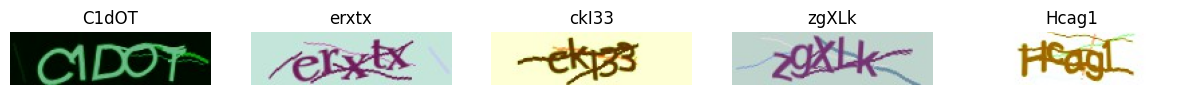

In [4]:
DATASET_PATH = '/Users/thanhduong/Downloads/archive'
IMG_HEIGHT = 40
IMG_WIDTH = 150
LABEL_LENGTH = 5

images = []
labels = []
    
for filename in os.listdir(DATASET_PATH):
    if filename.endswith('.jpg'):
        img_path = os.path.join(DATASET_PATH, filename)
        img = Image.open(img_path)
        images.append(np.array(img))
            
        label = filename[:-4]
        labels.append(label)

num_images = len(images)
print(f"Total number of images: {num_images}")

label_lengths = [len(label) for label in labels]
print(f"All labels are of length 5: {all(length == LABEL_LENGTH for length in label_lengths)}")
image_shapes = [img.shape for img in images]
image_heights = [shape[0] for shape in image_shapes]
image_widths = [shape[1] for shape in image_shapes]
print(f"All images are of size {IMG_HEIGHT}x{IMG_WIDTH}: {all(shape[0] == IMG_HEIGHT and shape[1] == IMG_WIDTH for shape in image_shapes)}")

# Randomly display 5 images with their labels and return the indices
indices = np.random.choice(len(images), 5, replace=False)
plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[idx])
    plt.title(labels[idx])
    plt.axis('off')
plt.show()


Processed images shape: (20000, 40, 150, 1)


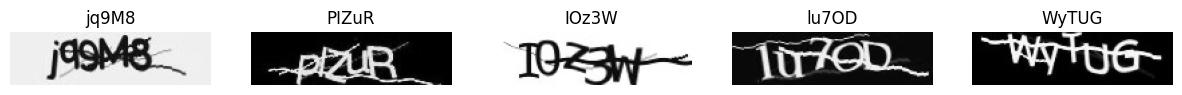

In [5]:
# Limit to 50,000 samples for efficiency (you can adjust as needed)
# Adjust
SAMPLE_SIZE = 20000
images = images[:SAMPLE_SIZE]
labels = labels[:SAMPLE_SIZE]
indices = np.random.choice(len(images), 5, replace=False)
# Adjust


# Convert to grayscale and normalize
images = np.array(images)

if images.ndim == 4 and images.shape[3] == 3:
    processed = np.dot(images[...,:3], [0.2989, 0.5870, 0.1140])
else:
    processed = images

processed = np.array(processed) / 255.0
if processed.ndim == 3:
    processed = np.expand_dims(processed, axis=-1)
print(f"Processed images shape: {processed.shape}")
# Double check by displaying the same indices
plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(processed[idx].squeeze(), cmap='gray')
    plt.title(labels[idx])
    plt.axis('off')
plt.show()

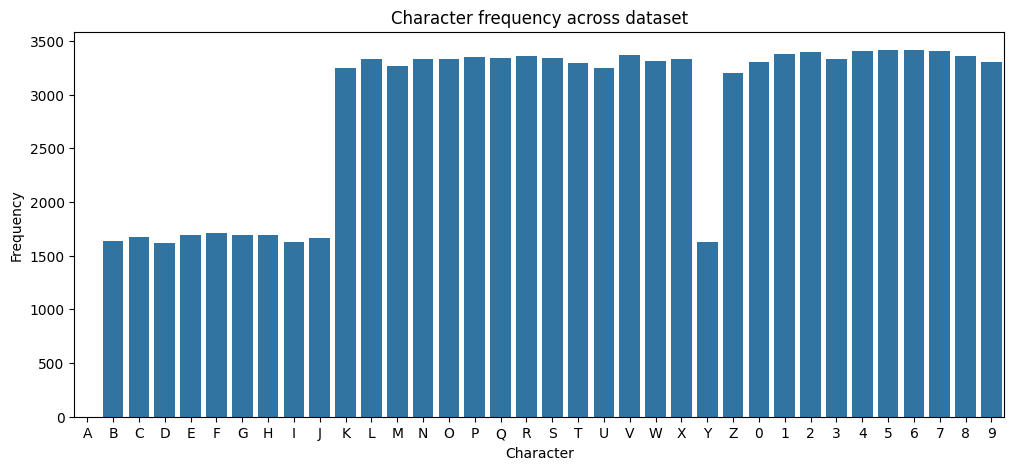

In [6]:
# Encode labels using one-hot encoding and visualize character frequency
char_set = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
le = LabelEncoder()
le.fit(list(char_set))

encoded_labels = np.zeros((len(labels), LABEL_LENGTH, len(char_set)))

for i, label in enumerate(labels):
    chars = list(label.upper())

    for j, char in enumerate(chars):
        char_idx = le.transform([char])[0]
        encoded_labels[i, j, char_idx] = 1

char_counts = encoded_labels.sum(axis=(0, 1))

plt.figure(figsize=(12, 5))
sns.barplot(x=list(char_set), y=char_counts)
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Character frequency across dataset")
plt.show()


In [7]:
#Data Splitting

X_train, X_temp, y_train, y_temp = train_test_split(processed, encoded_labels, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

y_train_split = [np.argmax(y_train[:, i, :], axis=1).astype('int32') for i in range(LABEL_LENGTH)]
y_val_split = [np.argmax(y_val[:, i, :], axis=1).astype('int32') for i in range(LABEL_LENGTH)]
y_test_split = [np.argmax(y_test[:, i, :], axis=1).astype('int32') for i in range(LABEL_LENGTH)]


In [8]:
# CNN Complication

VOCAB_SIZE = 36 
inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
    
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)
    
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)
    
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
    
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output_heads = [Dense(VOCAB_SIZE, activation='softmax', name=f'char_{i+1}')(x) for i in range(LABEL_LENGTH)]

model = Model(inputs=inputs, outputs=output_heads)
model.summary()

losses = {f'char_{i+1}': 'sparse_categorical_crossentropy' for i in range(LABEL_LENGTH)}
metrics = {f'char_{i+1}': 'accuracy' for i in range(LABEL_LENGTH)}
loss_weights = {f'char_{i+1}': 1.0 for i in range(LABEL_LENGTH)}

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=losses,
    metrics=metrics,
    loss_weights=loss_weights
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 40, 150,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 40, 150,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 40, 150,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 40, 150,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 150,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 20, 75,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 20, 75,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 20, 75,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 75,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 20, 75,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 75,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 37,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 37,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 10, 37,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 37,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 10, 37,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 37,    │        512 │ conv2d_5[0][0]  

 Total params: 6,367,636 (24.29 MB)

 Trainable params: 6,365,204 (24.28 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [10]:
# CNN Training
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True
    )
]


history = model.fit(
    X_train,
    y_train_split,
    validation_data=(X_val, y_val_split),  
    epochs=10,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/10
 22/125 ━━━━━━━━━━━━━━━━━━━━ 2:28 1s/step - char_1_accuracy: 0.0339 - char_1_loss: 4.9294 - char_2_accuracy: 0.0227 - char_2_loss: 4.9498 - char_3_accuracy: 0.0330 - char_3_loss: 4.8238 - char_4_accuracy: 0.0267 - char_4_loss: 4.9035 - char_5_accuracy: 0.0320 - char_5_loss: 4.9602 - loss: 24.5667

In [54]:
#Avoid retraining
# model = load_model('best_model.keras')
# history = model
#######

y_predict_cnn = model.predict(X_test)

y_pred_labels = np.array([np.argmax(y_pred, axis=1) for y_pred in y_predict_cnn]).T
y_true_labels = np.array([np.argmax(y_true, axis=1) for y_true in [y_test[:, i, :] for i in range(LABEL_LENGTH)]]).T

accuracies_cnn, precisions_cnn, recalls_cnn, f1_scores_cnn = [], [], [], []

for i in range(LABEL_LENGTH):
    print(f"Character {i+1} Classification Report")
    report = classification_report(y_true_labels[:, i], y_pred_labels[:, i], digits=4, output_dict=True)
    print(classification_report(y_true_labels[:, i], y_pred_labels[:, i], digits=4))
    
    accuracies_cnn.append(report["accuracy"])
    precisions_cnn.append(report["weighted avg"]["precision"])
    recalls_cnn.append(report["weighted avg"]["recall"])
    f1_scores_cnn.append(report["weighted avg"]["f1-score"])

plt.figure(figsize=(12, 6))
for i in range(LABEL_LENGTH):
    plt.plot(history.history[f'char_{i+1}_accuracy'], label=f'Char {i+1} Train Acc')
    plt.plot(history.history[f'val_char_{i+1}_accuracy'], linestyle='--', label=f'Char {i+1} Val Acc')

plt.title("Character-wise Accuracy During Training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

results = model.evaluate(
    X_test,
    [y_test[:, i, :] for i in range(LABEL_LENGTH)],
    verbose=1
)

mean_err = np.mean(results[::2]) 
mean_acc = np.mean(accuracies_cnn)
mean_pr = np.mean(precisions_cnn)
mean_re = np.mean(recalls_cnn)
mean_f1 = np.mean(f1_scores_cnn)

summary_df = pd.DataFrame({
    'Method': ['CNN'],
    'ERR': [round(mean_err, 3)],
    'ACC': [f"{mean_acc * 100:.2f}%"],
    'PR': [round(mean_pr, 3)],
    'RE': [round(mean_re, 3)],
    'F1': [round(mean_f1, 3)]
})

print("CNN Performance Table")
print()
print(summary_df.to_string(index=False))



157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step
Character 1 Classification Report
              precision    recall  f1-score   support

           1     0.9157    0.8352    0.8736        91
           2     1.0000    0.9882    0.9941        85
           3     1.0000    0.9674    0.9834        92
           4     0.9880    0.9647    0.9762        85
           5     1.0000    0.9674    0.9834        92
           6     1.0000    0.9605    0.9799        76
           7     0.9551    0.9884    0.9714        86
           8     0.9878    1.0000    0.9939        81
           9     1.0000    1.0000    1.0000        85
          10     0.9770    0.9884    0.9827       172
          11     0.9805    1.0000    0.9902       151
          12     0.9620    0.9725    0.9672       182
          13     1.0000    0.9750    0.9873       160
          14     0.9724    0.9670    0.9697       182
          15     0.9640    0.9781    0.9710       137
          16     0.9659    0.9942    0.9798       171
    

In [34]:
# SVM with HOG Features
def extract_hog_features(X):
    hog_features = []
    for img in X:
        feat = hog(img.reshape(40, 150), orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), block_norm='L2-Hys')
        hog_features.append(feat)
    return np.array(hog_features)

X_train_feat = extract_hog_features(X_train)
X_val_feat = extract_hog_features(X_val)
X_test_feat = extract_hog_features(X_test)

In [35]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

In [36]:
# From one-hot to single integer labels
y_train_labels = [np.argmax(y_train_split[i], axis=1) for i in range(LABEL_LENGTH)]
y_val_labels = [np.argmax(y_val_split[i], axis=1) for i in range(LABEL_LENGTH)]
y_test_labels = [np.argmax(y_test_split[i], axis=1) for i in range(LABEL_LENGTH)]

In [37]:
# SVM Training and Evaluation
svm_models = []
test_accuracies_svm = []
val_accuracies_svm = []
precisions_svm = []
recalls_svm = []
f1_scores_svm = []


for i in range(5):
    print(f"Training SVC for Character Position {i+1}")
    
    svm = LinearSVC(C=1.0, max_iter=1000, random_state=42, verbose=1)
    
    svm.fit(X_train_scaled, y_train_labels[i])
    
    y_val_pred = svm.predict(X_val_scaled)
    val_acc = accuracy_score(y_val_labels[i], y_val_pred)
    val_accuracies_svm.append(val_acc)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    y_test_pred = svm.predict(X_test_scaled)
    test_acc = accuracy_score(y_test_labels[i], y_test_pred)
    test_accuracies_svm.append(test_acc)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_labels[i], y_test_pred, average='weighted', zero_division=0
    )
    
    precisions_svm.append(precision)
    recalls_svm.append(recall)
    f1_scores_svm.append(f1)

    svm_models.append(svm)
    
    print(f"Test Accuracy: {test_acc:.4f}")



--- Training SVC for Character Position 1 ---
[LibLinear].....

/Users/thanhduong/Workspace/CAPTCHA-resolver/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


...............**
optimization finished, #iter = 208
Objective value = -0.538564
nSV = 747
...................*.*
optimization finished, #iter = 205
Objective value = -0.534735
nSV = 744
....................*
optimization finished, #iter = 207
Objective value = -0.534684
nSV = 755
......................*
optimization finished, #iter = 224
Objective value = -0.521363
nSV = 771
...................*
optimization finished, #iter = 198
Objective value = -0.548711
nSV = 728
...................**
optimization finished, #iter = 198
Objective value = -0.563065
nSV = 716
.....................*
optimization finished, #iter = 218
Objective value = -0.528273
nSV = 764
....................*
optimization finished, #iter = 207
Objective value = -0.544916
nSV = 747
....................**.
optimization finished, #iter = 210
Objective value = -0.534014
nSV = 755
....................*
optimization finished, #iter = 202
Objective value = -0.561409
nSV = 714
..................***
optimization finished, #ite

/Users/thanhduong/Workspace/CAPTCHA-resolver/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


.....................*
optimization finished, #iter = 221
Objective value = -0.526300
nSV = 763
....................*.**
optimization finished, #iter = 213
Objective value = -0.542237
nSV = 733
.....................*.*
optimization finished, #iter = 225
Objective value = -0.519735
nSV = 772
....................*
optimization finished, #iter = 207
Objective value = -0.524571
nSV = 769
...................**
optimization finished, #iter = 195
Objective value = -0.545544
nSV = 736
.....................*
optimization finished, #iter = 216
Objective value = -0.533425
nSV = 755
....................*
optimization finished, #iter = 207
Objective value = -0.533371
nSV = 746
...................**
optimization finished, #iter = 198
Objective value = -0.543942
nSV = 733
.......................*
optimization finished, #iter = 235
Objective value = -0.524542
nSV = 778
....................***.
optimization finished, #iter = 210
Objective value = -0.549132
nSV = 722
..................*
optimization fin

...

....................**
optimization finished, #iter = 219
Objective value = -0.536122
nSV = 751
.....................*
optimization finished, #iter = 212
Objective value = -0.534854
nSV = 750
.....................**
optimization finished, #iter = 219
Objective value = -0.535085
nSV = 750
.....................***
optimization finished, #iter = 218
Objective value = -0.541695
nSV = 739
...................*.**
optimization finished, #iter = 204
Objective value = -0.545970
nSV = 735
.....................*.
optimization finished, #iter = 220
Objective value = -0.523175
nSV = 766
....................***
optimization finished, #iter = 208
Objective value = -0.553834
nSV = 727
.....................*.*
optimization finished, #iter = 221
Objective value = -0.525514
nSV = 770
......................*
optimization finished, #iter = 225
Objective value = -0.529435
nSV = 761
...................*.*
optimization finished, #iter = 202
Objective value = -0.555963
nSV = 718
....................*
optimizat

/Users/thanhduong/Workspace/CAPTCHA-resolver/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


..................**
optimization finished, #iter = 216
Objective value = -0.527852
nSV = 754
...................*
optimization finished, #iter = 192
Objective value = -0.550375
nSV = 719
......................*
optimization finished, #iter = 226
Objective value = -0.534829
nSV = 750
.....................*
optimization finished, #iter = 216
Objective value = -0.537146
nSV = 754
.....................*
optimization finished, #iter = 212
Objective value = -0.537787
nSV = 751
.....................*.
optimization finished, #iter = 220
Objective value = -0.527946
nSV = 763
.....................**
optimization finished, #iter = 217
Objective value = -0.534518
nSV = 755
.....................*
optimization finished, #iter = 213
Objective value = -0.529472
nSV = 761
.....................*
optimization finished, #iter = 219
Objective value = -0.529459
nSV = 760
..................*.*
optimization finished, #iter = 193
Objective value = -0.578481
nSV = 702
...................*
optimization finished

/Users/thanhduong/Workspace/CAPTCHA-resolver/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


..................*
optimization finished, #iter = 206
Objective value = -0.531195
nSV = 759
.....................*
optimization finished, #iter = 216
Objective value = -0.530699
nSV = 759
....................**.*
optimization finished, #iter = 211
Objective value = -0.536423
nSV = 746
......................*
optimization finished, #iter = 226
Objective value = -0.519650
nSV = 777
....................*.**
optimization finished, #iter = 214
Objective value = -0.532136
nSV = 760
.....................**.*
optimization finished, #iter = 223
Objective value = -0.535055
nSV = 747
.....................*
optimization finished, #iter = 215
Objective value = -0.527025
nSV = 760
...................*.*
optimization finished, #iter = 201
Objective value = -0.526665
nSV = 755
....................*.*
optimization finished, #iter = 211
Objective value = -0.544792
nSV = 742
..................*
optimization finished, #iter = 183
Objective value = -0.561636
nSV = 707
...................***
optimization f

In [53]:
mean_acc_svm = np.mean(test_accuracies_svm)
mean_pr_svm = np.mean(precisions_svm)
mean_re_svm = np.mean(recalls_svm)
mean_f1_svm = np.mean(f1_scores_svm)

mean_err_svm = 1 - mean_acc_svm

summary_svm = pd.DataFrame({
    'Method': ['SVM'],
    'ERR': [round(mean_err_svm, 3)],
    'ACC': [f"{mean_acc_svm * 100:.2f}%"],
    'PR': [round(mean_pr_svm, 3)],
    'RE': [round(mean_re_svm, 3)],
    'F1': [round(mean_f1_svm, 3)]
})

print("\nSVM Performance Table")
print()
print(summary_svm.to_string(index=False))



SVM Performance Table

Method   ERR   ACC    PR    RE    F1
   SVM 0.936 6.40% 0.077 0.064 0.062
